In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_validate
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report,
    roc_auc_score,
    RocCurveDisplay,
    ConfusionMatrixDisplay
)
from sklearn.inspection import permutation_importance
from sklearn.compose import ColumnTransformer
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import confusion_matrix, make_scorer
from scipy.stats import uniform, randint
import shap
import xgboost as xgb

In [2]:
file_path = "globalterrorismdb_0522dist_csv.csv"
data = pd.read_csv(file_path, sep=";", encoding="latin1", low_memory=False)
print(f"Original Dataset shape: {data.shape}")

Original Dataset shape: (209706, 135)


In [ ]:
# Filter: data between 1998 and 2017

data = data[data["iyear"].between(1998, 2017)]

In [ ]:
# GTD-criteria

data = data[
    (data["crit1"] == 1) &
    (data["crit2"] == 1) &
    (data["crit3"] == 1)
]
print(f"Dataset shape after GTD-Filter: {data.shape}")

Dataset shape after GTD-Filter: (99492, 135)


In [ ]:
# Target variable (casualty occurrence)

# drop observation with NaNs in nkill and nwound
data = data.dropna(subset=["nkill", "nwound", "nkillter", "nwoundte"])

data["casualties"] = (data["nkill"] - data["nkillter"]) + (data["nwound"] - data["nwoundte"])
data["target"] = (data["casualties"] > 0).astype(int)

print("\nClass distribution of target variable:")
print(data["target"].value_counts())
print(f"Proportion of victims: {data['target'].mean():.2%}")
print(f"Dataset shape after NaN-Filter: {data.shape}")


Class distribution of target variable:
target
1    57330
0    33877
Name: count, dtype: int64
Proportion of victims: 62.86%
Dataset shape after NaN-Filter: (91207, 137)


In [ ]:
# 4️) convert numbers

for col in ["latitude", "longitude"]:
    if col in data.columns:
        data[col] = pd.to_numeric(
            data[col].astype(str).str.replace(',', '.', regex=False),
            errors='coerce'
        )

print(list(data.columns))


Features Zwischenstand:
['ï»¿eventid', 'iyear', 'imonth', 'iday', 'approxdate', 'extended', 'resolution', 'country', 'country_txt', 'region', 'region_txt', 'provstate', 'city', 'latitude', 'longitude', 'specificity', 'vicinity', 'location', 'summary', 'crit1', 'crit2', 'crit3', 'doubtterr', 'alternative', 'alternative_txt', 'multiple', 'success', 'suicide', 'attacktype1', 'attacktype1_txt', 'attacktype2', 'attacktype2_txt', 'attacktype3', 'attacktype3_txt', 'targtype1', 'targtype1_txt', 'targsubtype1', 'targsubtype1_txt', 'corp1', 'target1', 'natlty1', 'natlty1_txt', 'targtype2', 'targtype2_txt', 'targsubtype2', 'targsubtype2_txt', 'corp2', 'target2', 'natlty2', 'natlty2_txt', 'targtype3', 'targtype3_txt', 'targsubtype3', 'targsubtype3_txt', 'corp3', 'target3', 'natlty3', 'natlty3_txt', 'gname', 'gsubname', 'gname2', 'gsubname2', 'gname3', 'gsubname3', 'motive', 'guncertain1', 'guncertain2', 'guncertain3', 'individual', 'nperps', 'nperpcap', 'claimed', 'claimmode', 'claimmode_txt', 'c

In [ ]:
# Remove Features with too many Missing Values (>= 70%)

missing_ratio = data.isnull().mean()
drop_missing = missing_ratio[missing_ratio >= 0.7].index
print(f"Dropped Features (>= 70% NaNs): {len(drop_missing)}")
print(list(drop_missing))
data = data.drop(columns=drop_missing)
print(f"After Missing-Filter: {data.shape}")
print(list(data.columns))

Dropped Features (>= 70% NaNs): 70
['approxdate', 'resolution', 'alternative', 'alternative_txt', 'attacktype2', 'attacktype2_txt', 'attacktype3', 'attacktype3_txt', 'targtype2', 'targtype2_txt', 'targsubtype2', 'targsubtype2_txt', 'corp2', 'target2', 'natlty2', 'natlty2_txt', 'targtype3', 'targtype3_txt', 'targsubtype3', 'targsubtype3_txt', 'corp3', 'target3', 'natlty3', 'natlty3_txt', 'gsubname', 'gname2', 'gsubname2', 'gname3', 'gsubname3', 'guncertain2', 'guncertain3', 'claimmode', 'claimmode_txt', 'claim2', 'claimmode2', 'claimmode2_txt', 'claim3', 'claimmode3', 'claimmode3_txt', 'compclaim', 'weaptype2', 'weaptype2_txt', 'weapsubtype2', 'weapsubtype2_txt', 'weaptype3', 'weaptype3_txt', 'weapsubtype3', 'weapsubtype3_txt', 'weaptype4', 'weaptype4_txt', 'weapsubtype4', 'weapsubtype4_txt', 'propvalue', 'nhostkid', 'nhostkidus', 'nhours', 'ndays', 'divert', 'kidhijcountry', 'ransom', 'ransomamt', 'ransomamtus', 'ransompaid', 'ransompaidus', 'ransomnote', 'hostkidoutcome', 'hostkidoutc

In [ ]:
# Remove reduntant & high cardinality Features, Data Leakage

features_to_keep = [
    'attacktype1_txt', 'claimed', 'country_txt', 'crit1', 'crit2', 'crit3',
    'doubtterr', 'extended', 'gname', 'iday', 'imonth', 'ishostkid',
    'iyear', 'latitude', 'longitude', 'motive', 'multiple', 'natlty1_txt',
    'nkill', 'nwound', 'propcomment', 'property', 'propextent', 'region',
    'specificity', 'success', 'suicide', 'summary', 'target1', 'targtype1_txt',
    'vicinity', 'weaptype1_txt', 'target'
]

# drop features that are not in the list
cols_to_drop = [col for col in data.columns if col not in features_to_keep]
print(f"dropped Features: {len(cols_to_drop)}")
print(cols_to_drop)
data = data[features_to_keep]
print(f"After Feature Selection: {data.shape}")
print(f"\nRemaining Features ({len(data.columns)}):")
print(list(data.columns))

Gedropte Features: 34
['ï»¿eventid', 'country', 'region_txt', 'provstate', 'city', 'location', 'attacktype1', 'targtype1', 'targsubtype1', 'targsubtype1_txt', 'corp1', 'natlty1', 'guncertain1', 'individual', 'nperps', 'nperpcap', 'weaptype1', 'weapsubtype1', 'weapsubtype1_txt', 'weapdetail', 'nkillus', 'nkillter', 'nwoundus', 'nwoundte', 'propextent_txt', 'scite1', 'scite2', 'scite3', 'dbsource', 'INT_LOG', 'INT_IDEO', 'INT_MISC', 'INT_ANY', 'casualties']
After Feature Selection: (91207, 33)

Verbleibende Features (33):
['attacktype1_txt', 'claimed', 'country_txt', 'crit1', 'crit2', 'crit3', 'doubtterr', 'extended', 'gname', 'iday', 'imonth', 'ishostkid', 'iyear', 'latitude', 'longitude', 'motive', 'multiple', 'natlty1_txt', 'nkill', 'nwound', 'propcomment', 'property', 'propextent', 'region', 'specificity', 'success', 'suicide', 'summary', 'target1', 'targtype1_txt', 'vicinity', 'weaptype1_txt', 'target']


In [ ]:
# Cleaning (invalid coordinates & filters)
# Remove first row without coordinates (not imputable)
print("\nNumber differnt Values Doubt-Features:")
print(data["doubtterr"].value_counts())
print(data["doubtterr"].dtype)
data = data.dropna(subset=["latitude", "longitude"])
# Remove where both are 0 at the same time
data = data[~((data["latitude"] == 0) & (data["longitude"] == 0))]
data = data[(data["doubtterr"] == 0) & (data["ishostkid"] != -9) & (data["vicinity"] != -9)]

print(f"After Cleaning: {data.shape}")
print(f"Attacks with victims:    {data['target'].sum()}")
print(f"Attacks without victims: {(data['target'] == 0).sum()}")
print(f"Total:                   {len(data)}")
print(f"Proportion of victims:   {data['target'].mean():.2%}")
print(data["multiple"].value_counts())
print(data.groupby("multiple")["target"].mean())

data = data = data.drop(columns=["nkill", "nwound", "success", "crit1", "crit2", "crit3", "iday", "imonth", "iyear", "target1", "propcomment", "summary", "gname", "motive"])

print("\nFeatures after Preprocessing (before One-Hot-Encoding):")
print(list(data.columns))
feature_list = pd.DataFrame({"Feature": data.columns})
feature_list.to_csv("features_after_preprocessing_with_imputation.csv", index=False)
print("\nNumber Features:", len(data.columns) - 1)


Anzahl verschiedene Werte Doubt-Feature:
doubtterr
0    88757
1     2450
Name: count, dtype: int64
int64
After Cleaning: (88016, 33)
Attacks with victims:    55257
Attacks without victims: 32759
Total:                   88016
Proportion of victims:   62.78%
multiple
0.0    74201
1.0    13815
Name: count, dtype: int64
multiple
0.0    0.654196
1.0    0.486066
Name: target, dtype: float64

Features after Preprocessing (vor One-Hot-Encoding):
['attacktype1_txt', 'claimed', 'country_txt', 'doubtterr', 'extended', 'ishostkid', 'latitude', 'longitude', 'multiple', 'natlty1_txt', 'property', 'propextent', 'region', 'specificity', 'suicide', 'targtype1_txt', 'vicinity', 'weaptype1_txt', 'target']

Number Features: 18


In [ ]:
# define X and Y
X = data.drop(columns=["target"], errors="ignore")
y = data["target"]

print("X shape:", X.shape)
print("y shape:", y.shape)

num_cols_scale = data.select_dtypes(include=["number"]).columns.tolist()
num_cols_scale = [col for col in num_cols_scale if col != "target"]

scaler = MinMaxScaler()
data[num_cols_scale] = scaler.fit_transform(data[num_cols_scale])

print("Normalization finished (Min-Max, [0,1])")
print(f"Scaled Features: {num_cols_scale}")

X shape: (88016, 18)
y shape: (88016,)
Normalisierung abgeschlossen (Min-Max, [0,1])
Skalierte Features: ['claimed', 'doubtterr', 'extended', 'ishostkid', 'latitude', 'longitude', 'multiple', 'property', 'propextent', 'region', 'specificity', 'suicide', 'vicinity']


In [ ]:
# Train/Test Split (70/30) which is going to be validated at the end

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    stratify=y,
    random_state=42
)

print(f"X_train: {X_train.shape}")
print(f"X_test:  {X_test.shape}")
print(f"y_train: {y_train.shape}")
print(f"y_test:  {y_test.shape}")

X_train: (61611, 18)
X_test:  (26405, 18)
y_train: (61611,)
y_test:  (26405,)


In [ ]:
# RF based feature selection

X_rf = X_train.copy()
y_rf = y_train.copy()

cat_cols_rf = X_rf.select_dtypes(include=["object"]).columns.tolist()

X_rf_encoded = X_rf.copy()

for col in cat_cols_rf:
    X_rf_encoded[col] = pd.factorize(X_rf_encoded[col])[0]

# train RF
rf_model = RandomForestClassifier(
    n_estimators=500,
    random_state=42,
    n_jobs=-1,
    oob_score=True
)

rf_model.fit(X_rf_encoded, y_rf)

# Permutation importance
perm = permutation_importance(
    rf_model,
    X_rf_encoded,
    y_rf,
    n_repeats=10,
    random_state=42,
    n_jobs=-1
)

importance_df = pd.DataFrame({
    "feature": X_rf_encoded.columns,
    "importance": perm.importances_mean,
    "importance_std": perm.importances_std
}).sort_values("importance", ascending=False)

ranked_features = importance_df["feature"].tolist()

print("Top Features:")
print(importance_df.head(15))

Top Features:
            feature  importance  importance_std
15    targtype1_txt    0.168048        0.000914
6          latitude    0.090206        0.000811
0   attacktype1_txt    0.089554        0.000781
7         longitude    0.088781        0.000538
17    weaptype1_txt    0.081859        0.001167
10         property    0.064141        0.000529
9       natlty1_txt    0.039801        0.000811
2       country_txt    0.038803        0.000526
8          multiple    0.035492        0.000297
11       propextent    0.026156        0.000380
13      specificity    0.025955        0.000463
1           claimed    0.021008        0.000333
12           region    0.016072        0.000275
14          suicide    0.013074        0.000227
16         vicinity    0.009776        0.000408


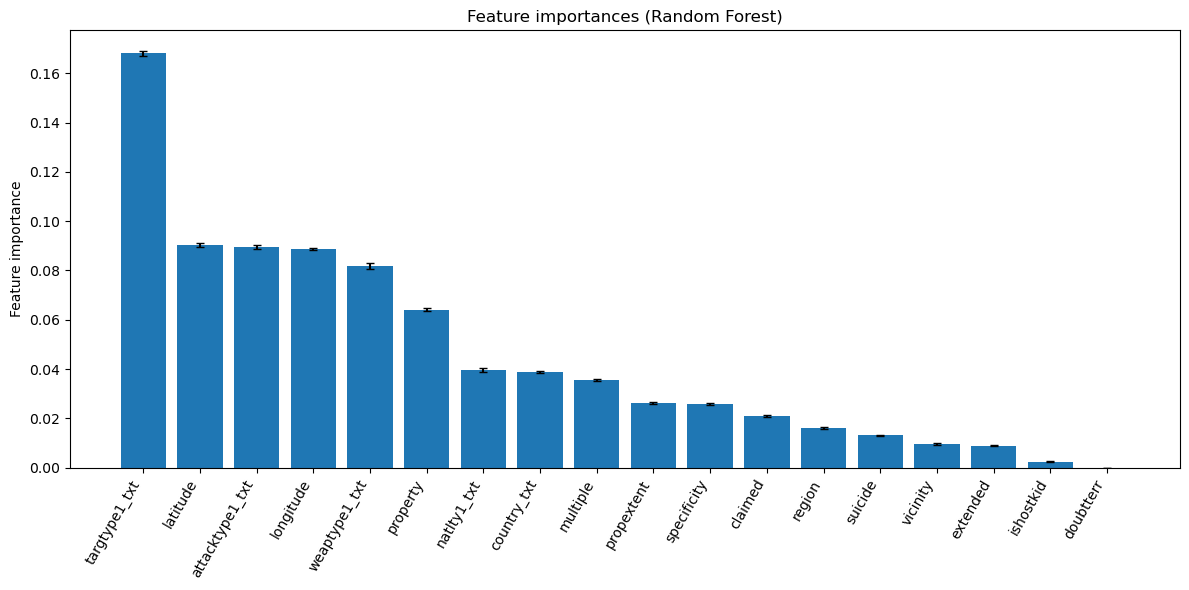

In [ ]:
plot_df = importance_df.head(20)

# prepare data
features = plot_df["feature"]
importances = plot_df["importance"]
errors = plot_df["importance_std"]

# Plot
plt.figure(figsize=(12, 6))

plt.bar(
    features,
    importances,
    yerr=errors,
    capsize=3
)

plt.xticks(rotation=60, ha="right")
plt.ylabel("Feature importance")
plt.title("Feature importances (Random Forest)")

plt.tight_layout()
plt.show()

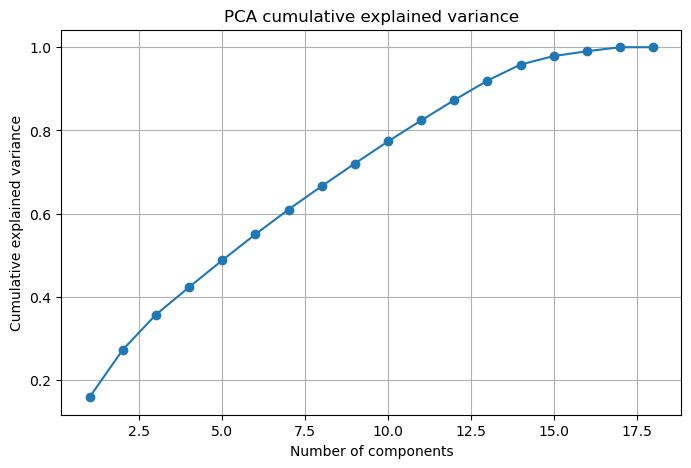

In [ ]:
# PCA to determine ideal number of features

X_pca = X_rf.copy()

num_cols = X_pca.select_dtypes(include=["number"]).columns
cat_cols = X_pca.select_dtypes(include=["object"]).columns

X_pca[num_cols] = X_pca[num_cols].fillna(X_pca[num_cols].median())
X_pca[cat_cols] = X_pca[cat_cols].fillna("Unknown")

for col in cat_cols:
    X_pca[col] = pd.factorize(X_pca[col])[0]

# Scale
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_pca)

# PCA
pca = PCA()
pca.fit(X_scaled)

explained_variance = np.cumsum(pca.explained_variance_ratio_)

# Plot
plt.figure(figsize=(8,5))

plt.plot(range(1, len(explained_variance)+1), explained_variance, marker="o")

plt.xlabel("Number of components")
plt.ylabel("Cumulative explained variance")
plt.title("PCA cumulative explained variance")

plt.grid()
plt.show()

In [ ]:
# determine final feature set
T = 15

features_to_exclude = [
    "target1",
    "propcomment",
    "iyear"
]

ranked_features_filtered = [
    feature for feature in ranked_features
    if feature not in features_to_exclude
]

selected_features = ranked_features_filtered[:T]

print("Selected features:")
print(selected_features)

X_model = X_train[selected_features].copy()
y_model = y_train.copy()

print("Selected features:", selected_features)
print("X_model shape:", X_model.shape)
print("X_model shape:", X_model.shape)
print("y_model shape:", y_model.shape)
print("Excluded features:")
print(features_to_exclude)
print("Number of selected features:", len(selected_features))

Selected features:
['targtype1_txt', 'latitude', 'attacktype1_txt', 'longitude', 'weaptype1_txt', 'property', 'natlty1_txt', 'country_txt', 'multiple', 'propextent', 'specificity', 'claimed', 'region', 'suicide', 'vicinity']
Selected features: ['targtype1_txt', 'latitude', 'attacktype1_txt', 'longitude', 'weaptype1_txt', 'property', 'natlty1_txt', 'country_txt', 'multiple', 'propextent', 'specificity', 'claimed', 'region', 'suicide', 'vicinity']
X_model shape: (88016, 15)
X_model shape: (88016, 15)
y_model shape: (88016,)
Excluded features:
['target1', 'propcomment', 'iyear']
Number of selected features: 15


In [ ]:
# Preprocessing for selected features (imputaton here and not earlier to prevent data leakage)

num_cols_model = X_model.select_dtypes(include=["number"]).columns.tolist()
cat_cols_model = X_model.select_dtypes(include=["object"]).columns.tolist()

num_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
])

cat_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("ohe", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor_model = ColumnTransformer([
    ("num", num_pipeline, num_cols_model),
    ("cat", cat_pipeline, cat_cols_model)
])

In [ ]:
# XGBoost pipeline

from xgboost import XGBClassifier

xgb_pipeline = Pipeline([
    ("preprocessing", preprocessor_model),
    ("model", XGBClassifier(
        random_state=42,
        eval_metric="logloss"
    ))
])

print(xgb_pipeline)

Pipeline(steps=[('preprocessing',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median'))]),
                                                  ['latitude', 'longitude',
                                                   'property', 'multiple',
                                                   'propextent', 'specificity',
                                                   'claimed', 'region',
                                                   'suicide', 'vicinity']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('ohe',
                              

In [ ]:
# hyperparameter tuning (practical replication of GA-XGBoost)

def gmean_score(y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
    return np.sqrt(recall * specificity)

gmean_scorer = make_scorer(gmean_score)

param_dist = {
    "model__n_estimators":      randint(10, 1000),    # [10, 1000]
    "model__learning_rate":     uniform(0.01, 0.99),  # [0.01, 1]
    "model__max_depth":         randint(1, 15),        # [1, 15]
    "model__min_child_weight":  randint(1, 10),        # [1, 10]
    "model__gamma":             uniform(0.1, 0.9),     # [0.1, 1]
    "model__subsample":         uniform(0.1, 0.9),     # [0.1, 1]
    "model__colsample_bytree":  uniform(0.1, 0.9),    # [0.1, 1]
}

cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)  # 10-fold wie im Artikel

scoring = {
    "accuracy":  "accuracy",
    "precision": "precision",
    "recall":    "recall",
    "f1":        "f1",
    "roc_auc":   "roc_auc",
    "gmean":     gmean_scorer
}

random_search = RandomizedSearchCV(
    estimator=xgb_pipeline,
    param_distributions=param_dist,
    n_iter=50, 
    scoring=scoring,
    refit="f1", 
    cv=cv,
    verbose=1,
    n_jobs=-1,
    random_state=42,
    return_train_score=False
)

random_search.fit(X_model, y_model)

print("Best parameters:")
print(random_search.best_params_)
print(f"\nBest CV F1-score: {random_search.best_score_:.4f}")

best_index = random_search.best_index_
print("\nCross-validated performance of best model:")
for metric in scoring:
    print(f"{metric}: {random_search.cv_results_[f'mean_test_{metric}'][best_index]:.4f}")

Fitting 10 folds for each of 50 candidates, totalling 500 fits
Best parameters:
{'model__colsample_bytree': np.float64(0.3528410587186427), 'model__gamma': np.float64(0.5884264748424236), 'model__learning_rate': np.float64(0.14951498272501504), 'model__max_depth': 13, 'model__min_child_weight': 1, 'model__n_estimators': 866, 'model__subsample': np.float64(0.9881982429404655)}

Best CV F1-score: 0.8793

Cross-validated performance of best model:
accuracy: 0.8437
precision: 0.8534
recall: 0.9067
f1: 0.8793
roc_auc: 0.9109
gmean: 0.8176


In [ ]:
# Final Evaluation of Testdata (one time)

X_test_final = X_test[selected_features].copy()

y_pred = random_search.predict(X_test_final)
y_prob = random_search.predict_proba(X_test_final)[:, 1]

print(classification_report(y_test, y_pred,
      target_names=["No casualties", "Casualties"]))
print(f"ROC-AUC: {roc_auc_score(y_test, y_prob):.4f}")

              precision    recall  f1-score   support

 Keine Opfer       0.87      0.78      0.82      9828
       Opfer       0.88      0.93      0.90     16577

    accuracy                           0.88     26405
   macro avg       0.87      0.86      0.86     26405
weighted avg       0.87      0.88      0.87     26405

ROC-AUC: 0.9417


In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import GradientBoostingClassifier

cv_compare = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

models = {
    "Decision Tree": Pipeline([
        ("preprocessing", preprocessor_model),
        ("model", DecisionTreeClassifier(random_state=42))
    ]),
    "Random Forest": Pipeline([
        ("preprocessing", preprocessor_model),
        ("model", RandomForestClassifier(random_state=42, n_jobs=-1))
    ]),
    "GBDT": Pipeline([
        ("preprocessing", preprocessor_model),
        ("model", GradientBoostingClassifier(random_state=42))
    ]),
    "Logistic Regression": Pipeline([
        ("preprocessing", preprocessor_model),
        ("model", LogisticRegression(random_state=42, max_iter=1000))
    ])
}

results = {}

for name, pipeline in models.items():
    print(f"\nTrain {name}...")
    cv_res = cross_validate(
        pipeline,
        X_model,
        y_model,
        cv=cv_compare,
        scoring=scoring,
        n_jobs=-1
    )
    results[name] = {
        metric: cv_res[f"test_{metric}"].mean()
        for metric in scoring
    }
    print(f"  F1:     {results[name]['f1']:.4f}")
    print(f"  AUC:    {results[name]['roc_auc']:.4f}")
    print(f"  Recall: {results[name]['recall']:.4f}")

best_index = random_search.best_index_
results["GA-XGBoost"] = {
    metric: random_search.cv_results_[f"mean_test_{metric}"][best_index]
    for metric in scoring
}

In [ ]:
results_df = pd.DataFrame(results).T
results_df = results_df[["accuracy", "recall", "precision", "f1", "roc_auc", "gmean"]]
results_df.columns = ["Accuracy", "Sensitivity", "Precision", "F1-score", "AUC", "G-mean"]
results_df = results_df.round(4)

print("\nComparison of all models (10-fold CV):")
print(results_df.to_string())
results_df.to_csv("model_comparison_15features.csv")

In [ ]:
print("\nFinale Evaluation auf Testset:")
print("="*60)

for name, pipeline in models.items():
    pipeline.fit(X_model, y_model)
    y_pred_test = pipeline.predict(X_test_final)
    y_prob_test = pipeline.predict_proba(X_test_final)[:, 1]
    auc = roc_auc_score(y_test, y_prob_test)
    print(f"\n{name}:")
    print(classification_report(y_test, y_pred_test,
          target_names=["No Casualties", "Casualties"]))
    print(f"AUC: {auc:.4f}")

In [ ]:
best_xgb = random_search.best_estimator_

X_test_preprocessed = best_xgb.named_steps["preprocessing"].transform(X_test_final)

ohe_feature_names = (
    best_xgb.named_steps["preprocessing"]
    .named_transformers_["cat"]
    .named_steps["ohe"]
    .get_feature_names_out(cat_cols_model)
)

all_feature_names = num_cols_model + list(ohe_feature_names)

if hasattr(X_test_preprocessed, "toarray"):
    X_test_preprocessed = X_test_preprocessed.toarray()

xgb_model = best_xgb.named_steps["model"]

dmatrix = xgb.DMatrix(
    X_test_preprocessed,
    feature_names=all_feature_names
)

shap_contribs = xgb_model.get_booster().predict(
    dmatrix,
    pred_contribs=True
)

shap_values = shap_contribs[:, :-1]


ohe_col_to_original = {}
for orig_col in cat_cols_model:
    for ohe_col in ohe_feature_names:
        if ohe_col.startswith(orig_col + "_"):
            ohe_col_to_original[ohe_col] = orig_col

original_features = num_cols_model + cat_cols_model
shap_aggregated = np.zeros((shap_values.shape[0], len(original_features)))

for i, feat in enumerate(original_features):
    if feat in num_cols_model:
        col_idx = all_feature_names.index(feat)
        shap_aggregated[:, i] = shap_values[:, col_idx]
    else:
        ohe_indices = [
            j for j, name in enumerate(all_feature_names)
            if ohe_col_to_original.get(name) == feat
        ]
        shap_aggregated[:, i] = shap_values[:, ohe_indices].sum(axis=1)


print("shap_aggregated shape:", shap_aggregated.shape)

plt.figure(figsize=(10, 6))

shap.summary_plot(
    shap_aggregated,
    pd.DataFrame(shap_aggregated, columns=original_features),
    feature_names=original_features,
    max_display=15, 
    show=False
)

plt.tight_layout()
plt.savefig("shap_summary_plot_fifteen_features.png", dpi=150, bbox_inches="tight")
plt.show()

print("SHAP Plot saved as shap_summary_plot_fifteen_features.png")

In [ ]:
print("selected_features:", selected_features)
print("num_cols_model:", num_cols_model)
print("cat_cols_model:", cat_cols_model)
print("all_feature_names:", all_feature_names[:15])
print("shap_values shape:", shap_values.shape)
print("shap_aggregated shape:", shap_aggregated.shape)
print("original_features:", original_features)
print("Spalten in shap_aggregated:", list(pd.DataFrame(shap_aggregated, columns=original_features).columns))

In [ ]:
# best parameters and best score 

print("Best parameters:")
print(random_search.best_params_)

print("\nBest CV F1-score:")
print(random_search.best_score_)

Best parameters:
{'model__colsample_bytree': np.float64(0.3528410587186427), 'model__gamma': np.float64(0.5884264748424236), 'model__learning_rate': np.float64(0.14951498272501504), 'model__max_depth': 13, 'model__min_child_weight': 1, 'model__n_estimators': 866, 'model__subsample': np.float64(0.9881982429404655)}

Best CV F1-score:
0.8792719317055908


In [ ]:
# evaluate best model with multiple metrics

best_pipeline = random_search.best_estimator_

scoring = {
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
    "roc_auc": "roc_auc",
    "gmean": gmean_scorer
}

cv_results = cross_validate(
    best_pipeline,
    X_model,
    y_model,
    cv=cv,
    scoring=scoring,
    n_jobs=-1
)

for metric in scoring:
    scores = cv_results[f"test_{metric}"]
    print(f"{metric}: {scores.mean():.4f} ± {scores.std():.4f}")

accuracy: 0.8437 ± 0.0025
precision: 0.8534 ± 0.0034
recall: 0.9067 ± 0.0026
f1: 0.8793 ± 0.0017
roc_auc: 0.9109 ± 0.0027
gmean: 0.8176 ± 0.0037
